In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [163]:
import pandas as pd
df= pd.read_csv(r"C:\Users\dell\Downloads\car data.csv")   # 👈 replace
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [165]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [166]:
#dropping car name not useful for model
from datetime import datetime
df.drop('Car_Name',axis=1,inplace=True)
df['Car_Age']=datetime.now().year-df['Year']
df.drop('Year',axis=1,inplace=True)

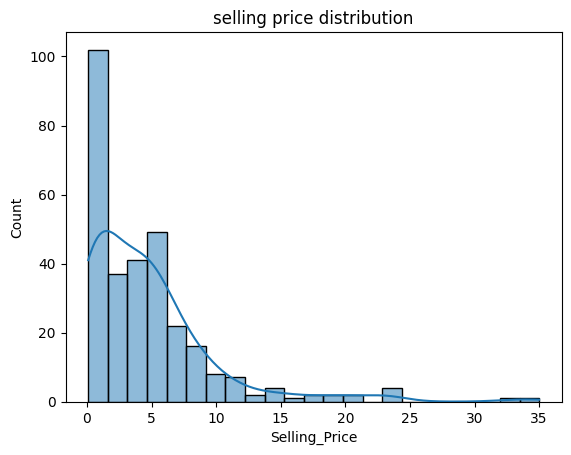

In [167]:
sns.histplot(df['Selling_Price'],kde=True)
plt.title("selling price distribution")
plt.show()

In [168]:
print("Inference: Most cars are low priced distribution is skew")

Inference: Most cars are low priced distribution is skew


Text(0.5, 1.0, 'car age vs selling price')

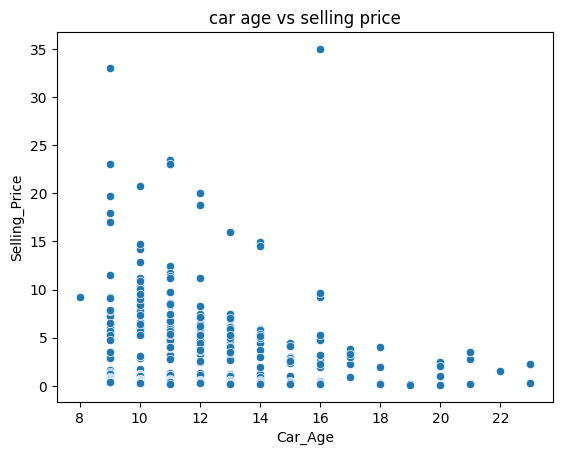

In [169]:
sns.scatterplot(x=df['Car_Age'],y=df['Selling_Price'])
plt.title('car age vs selling price')

In [170]:
print('Insight: As car age increases selling price decreases')

Insight: As car age increases selling price decreases


Text(0.5, 1.0, 'KM Driven vs Selling Price')

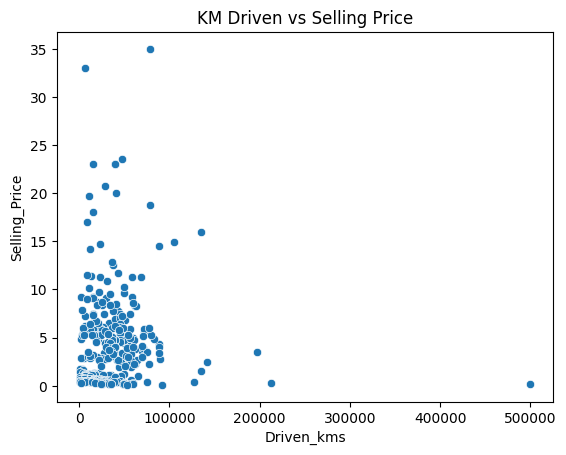

In [171]:
sns.scatterplot(x=df['Driven_kms'],y=df['Selling_Price'])
plt.title('KM Driven vs Selling Price')

In [172]:
print("Insight: More usage -> less price")

Insight: More usage -> less price


In [173]:
df=pd.get_dummies(df,drop_first=True)

In [174]:
corr=df.corr()['Selling_Price'].sort_values(ascending=False)
print(corr)

Selling_Price              1.000000
Present_Price              0.878914
Fuel_Type_Diesel           0.552339
Driven_kms                 0.029187
Owner                     -0.088344
Car_Age                   -0.236141
Transmission_Manual       -0.367128
Fuel_Type_Petrol          -0.540571
Selling_type_Individual   -0.550724
Name: Selling_Price, dtype: float64


In [175]:
x=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

In [176]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [177]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [178]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)

from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.1)
lasso.fit(x_train,y_train)
y_pred_lasso=lasso.predict(x_test)

In [179]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
def evaluate(y_true,y_pred,name):
    print(f"{name}")
    print("MAE",mean_absolute_error(y_true,y_pred,))
    print(f"{name}")
    print("RMSE",mean_squared_error(y_true,y_pred,))
    print(f"{name}")
    print("R2 Score",r2_score(y_true,y_pred,))   
evaluate(y_test,y_pred_lr,"Linear Regression")
evaluate(y_test,y_pred_lr,"Lasso Regression")

Linear Regression
MAE 1.2163740193330423
Linear Regression
RMSE 3.4813498305118595
Linear Regression
R2 Score 0.8488707839193136
Lasso Regression
MAE 1.2163740193330423
Lasso Regression
RMSE 3.4813498305118595
Lasso Regression
R2 Score 0.8488707839193136


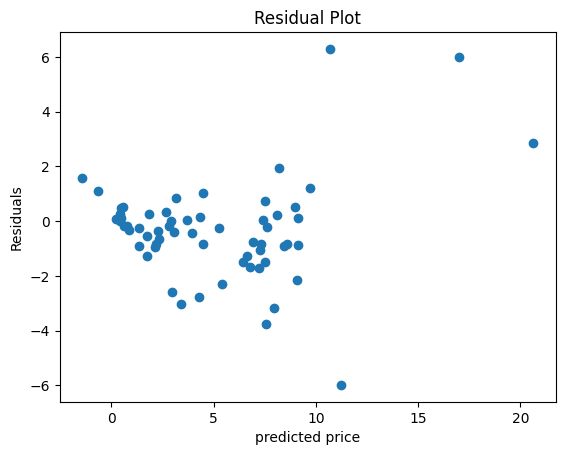

In [180]:
residuals=y_test-y_pred_lr
plt.scatter(y_pred_lr,residuals)
plt.xlabel("predicted price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [181]:
print("inference: Random scatter model is good")

inference: Random scatter model is good


Text(0.5, 1.0, 'Error Distribution')

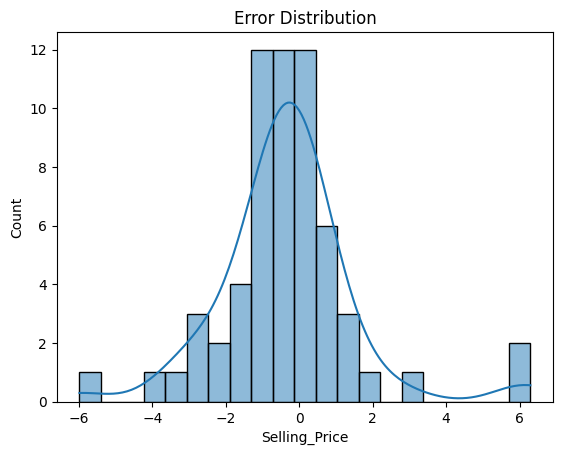

In [182]:
sns.histplot(residuals,kde=True)
plt.title("Error Distribution")

In [183]:
print("errors centred near zero good model")

errors centred near zero good model



Top important features
 Owner              -0.159274
Driven_kms         -0.133483
Fuel_Type_Petrol   -0.000000
Fuel_Type_Diesel    0.632569
Present_Price       3.823579
dtype: float64


Text(0.5, 1.0, 'Important features')

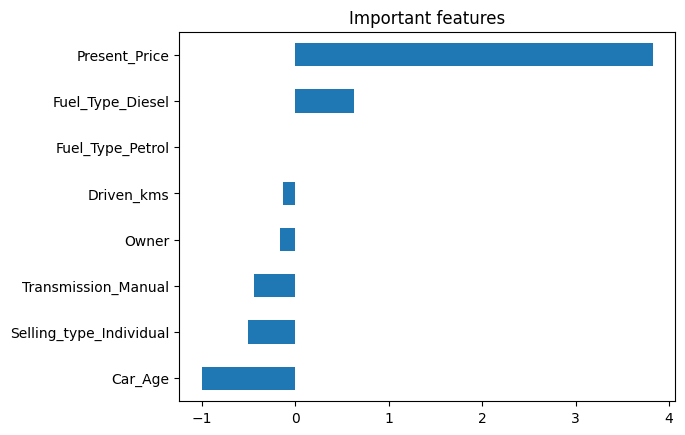

In [185]:
coef=pd.Series(lasso.coef_,index=x.columns)
print("\nTop important features\n",coef.sort_values().tail(5))
coef.sort_values().tail(10).plot(kind='barh')
plt.title("Important features")

In [187]:
train_score=lr.score(x_train,y_train)
test_score=lr.score(x_test,y_test)
print("train R2:",train_score)
print("test R2:",test_score)

train R2: 0.8883342470084291
test R2: 0.8488707839193136


In [188]:
train_score=lasso.score(x_train,y_train)
test_score=lasso.score(x_test,y_test)
print("train R2:",train_score)
print("test R2:",test_score)

train R2: 0.8863374302959091
test R2: 0.844440978924247


In [191]:
print("linear R2:",r2_score(y_test,y_pred_lr))
print("lasso R2:",r2_score(y_test,y_pred_lasso))

linear R2: 0.8488707839193136
lasso R2: 0.8444409789242471


In [ ]:
print("\n Final Insights:")
print("- Car age and km driven reduce price")
print("- Present price strongly affects selling price")
print("- Fuel type & transmission impact price")
print("- Lasso helps identify important features")
print("- Model performs well with linear assumptions")